<a href="https://colab.research.google.com/github/princeiiitk/CumpusX_DL/blob/main/ANN/Customer_churn_prediction_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
!git clone 'https://github.com/princeiiitk/CumpusX_DL'

fatal: destination path 'CumpusX_DL' already exists and is not an empty directory.


In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
df=pd.read_csv('/content/CumpusX_DL/ANN/Churn_Modelling.csv')

In [82]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [83]:
df.shape

(10000, 14)

In [84]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [85]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [86]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [87]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [88]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [89]:
df=pd.get_dummies(df,columns=['Gender','Geography'],drop_first=True)

In [90]:
df.astype(int)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Male,Geography_Germany,Geography_Spain
0,619,42,2,0,1,1,1,101348,1,0,0,0
1,608,41,1,83807,1,0,1,112542,0,0,0,1
2,502,42,8,159660,3,1,0,113931,1,0,0,0
3,699,39,1,0,2,0,0,93826,0,0,0,0
4,850,43,2,125510,1,1,1,79084,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0,2,1,0,96270,0,1,0,0
9996,516,35,10,57369,1,1,1,101699,0,1,0,0
9997,709,36,7,0,1,0,1,42085,1,0,0,0
9998,772,42,3,75075,2,1,0,92888,1,1,1,0


In [91]:
X=df.drop(columns=['Exited'])
y=df['Exited']

In [92]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=20)

In [93]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [94]:
X_train

array([[ 1.34111823,  0.38693948, -1.73661451, ..., -1.08948952,
        -0.57965968, -0.58042949],
       [-1.4670728 , -0.57127623,  0.69033796, ...,  0.91786105,
        -0.57965968, -0.58042949],
       [-0.19155746, -1.62531351, -0.69649202, ..., -1.08948952,
        -0.57965968, -0.58042949],
       ...,
       [ 0.5079187 ,  1.44097676, -0.69649202, ..., -1.08948952,
         1.72515018, -0.58042949],
       [-2.25912668, -0.76291937, -0.00307703, ...,  0.91786105,
        -0.57965968, -0.58042949],
       [-0.78816947,  1.05769048, -1.73661451, ...,  0.91786105,
        -0.57965968,  1.72286214]])

In [95]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [96]:
model=Sequential()
model.add(Dense(11,activation='sigmoid',input_dim=11))
model.add(Dense(11,activation='sigmoid'))
model.add(Dense(1,activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [97]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [98]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['Accuracy'])

In [99]:
history=model.fit(X_train,y_train,batch_size=50,epochs=15,verbose=1,validation_split=0.2)

Epoch 1/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - Accuracy: 0.7903 - loss: 0.5095 - val_Accuracy: 0.8012 - val_loss: 0.4849
Epoch 2/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Accuracy: 0.7903 - loss: 0.4963 - val_Accuracy: 0.8012 - val_loss: 0.4716
Epoch 3/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Accuracy: 0.7903 - loss: 0.4820 - val_Accuracy: 0.8012 - val_loss: 0.4549
Epoch 4/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Accuracy: 0.7903 - loss: 0.4646 - val_Accuracy: 0.8012 - val_loss: 0.4380
Epoch 5/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.7928 - loss: 0.4491 - val_Accuracy: 0.8100 - val_loss: 0.4243
Epoch 6/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Accuracy: 0.8023 - loss: 0.4389 - val_Accuracy: 0.8138 - val_loss: 0.4179
Epoch 7/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Accuracy: 0.8070 - loss: 0.4338 - val_Accuracy: 0.8150 - val_loss: 0.4127
Epoch 8/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Accuracy: 0.8078 - loss: 0.4307 - val_Accuracy: 0.

In [105]:
y_pred=model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [106]:
y_predict.shape

(2000, 1)

In [107]:
X_train.shape

(8000, 11)

In [108]:
y_pred = (y_pred > 0.5).astype(int)

In [109]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8285

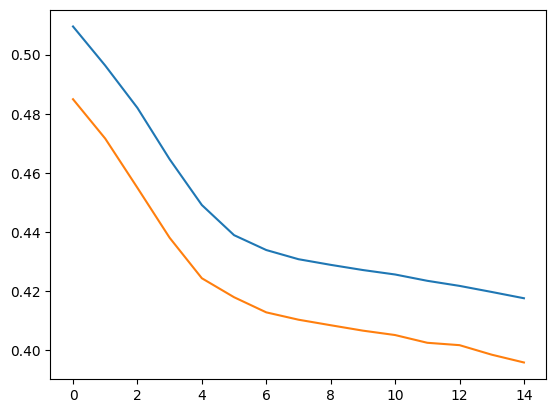

In [110]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])